In [ ]:
# default_exp genetic

# Genetic algorithms
> This module contains the utilities needed to optimize using a genetic algorithms

In [ ]:
#hide
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
from typing import Generator, NewType, List
from typing import Iterable, List
from typing import Callable

from itertools import islice

## Genetic Algorithm implementation

In [ ]:
#exporti
def gen_consecutive_tuples(_list, tuple_size = 2):
    """
    Of the sequence [1, 2, 3, 4, 5, 6, ..] return a generator that yields (1, 2), (3, 4), (5, 6), .. 
    """
    yield from zip(*(_list[i::tuple_size] for i in range(tuple_size)))

def take(size, generator):
    return np.array(list(islice(generator, size)))

In [ ]:
Individual = NewType("Individual", np.ndarray)  # a vector of bytes ( so a 1D array)
Generation = NewType("Generation", np.ndarray)  # a collection of individuals (so 2D array)


def initial_generation(population_size: int, dna_size) -> Generation:
    return np.random.choice([0, 1], size=(population_size, dna_size))

def elite_individuals(individuals: Generation, fitness_values: np.ndarray,
                      number_of_elite_individuals: int) -> Generation:
    """
    Select x% (usually 10%) of the population
    pass these individuals into the new generation
    """
    assert number_of_elite_individuals >= 1, f"Expecting to have at least 1 elite individual but received {number_of_elite_individuals}"
    k_largest_indices = np.argpartition(fitness_values, kth=-int(number_of_elite_individuals))[
                        -int(number_of_elite_individuals):]
    return individuals[k_largest_indices]


def proportional_individuals(individuals, fitness_values, number_of_proportional_individuals, debug=False):
    """
    We compute a probability dist function of selection, based on the distance of each
    individual's finess from the best performing individual and sample from that

    pdf = (1 - (np.max(f) − f) / (np.max(f) - np.min(f))) / np.sum( 1 - (np.max(f) − f) / (np.max(f) - np.min(f)))
    np.random.choice(individuals, p=pdf)
    """
    if debug: print(f"F: {fitness_values}")
    if len(np.unique(fitness_values)) == 1: 
        # edge case where all probabilities are equal, which will lead
        # to them being min-maxed all to 0, which will lead to a 0 / 0 division
        # and a np.NaN filled array in the random pdf
        #
        # as such, when we have only one unique value we manually construct a uniform
        # distribution
        pdf = np.full_like(fitness_values, 1/len(fitness_values))       
    else:
        pdf = (np.max(fitness_values) - fitness_values) / (
                np.max(fitness_values) - np.min(fitness_values)
        )  # min-max scale
        # pdf = (fitness_values - np.min(fitness_values)) / (np.max(fitness_values) - np.min(fitness_values))

        pdf = 1 - pdf  # invert the probabilities
        pdf = pdf / np.sum(pdf)  # make it a pdf
    
    if debug: print(f"PDF: {pdf}\n")
    selected_indices = np.random.choice(
        np.arange(individuals.shape[0]),
        size=int(number_of_proportional_individuals),
        p=pdf,
        replace=True
    )
    return individuals[selected_indices, :]

def tournament_individuals(individuals, fitness_values, number_of_tournaments, tournament_size=2):
    """
    Choose multiple times, `tournament_size` random individuals (with replacement)
    pass on, the individual with the best performing fitness function from the selection
    """

    shuffled_individuals = np.random.permutation(individuals.shape[0])
    assert individuals.shape[0] // tournament_size >= number_of_tournaments, f"We don't have enough elements in the list to generate all the required ({number_of_tournaments}) tournaments from a single shuffle (size = {individuals.shape[0]}). Using it we can only generated a maximum of {individuals.shape[0] // tournament_size} tournaments of size {tournament_size}. We may require doing a second shuffle for the rest of {number_of_tournaments - individuals.shape[0] // tournament_size} the tournaments."

    tournaments = take(number_of_tournaments, gen_consecutive_tuples(shuffled_individuals, tuple_size=tournament_size))
    tournament_winners = [
        competitors[np.argmax(fitness_values[competitors])]
        for competitors in tournaments
    ]
    return individuals[tournament_winners]


def mutation(individuals: Generation, mutation_chance=0.05) -> Generation:
    """
    For each individual
        select x% of it's genes
        change the genes selected

    This is the XOR operation:

    gene   mask   gene
    0       0   => 0
    0       1   => 1
    1       0   => 1
    1       1   => 0

    """
    mutation_mask = np.random.choice([0, 1], size=individuals.shape, p=[1 - mutation_chance, mutation_chance])
    return individuals ^ mutation_mask


def cross_over(individuals: Generation) -> Generation:
    print(f"cross_over: individuals.shape={individuals.shape}")

    shuffled_individuals = np.random.permutation(individuals.shape[0])
    crossovers = take(individuals.shape[0] // 2, gen_consecutive_tuples(shuffled_individuals))
    assert individuals.shape[0] % 2 == 0, f"We need to have an even number of individuals in the generation so we can pair each one up with a different mate in the crossover stage. We've received {individuals.shape[0]} individuals in the generation. For an odd number of individuals we will end up crossing over an individual twice (with another mate)."


    children = individuals.copy()
    locuses = np.random.randint(1, individuals.shape[1] - 1, size=(individuals.shape[0],))
    for i, (crossover_locus, (male, female)) in enumerate(zip(locuses, crossovers)):
        print(i, crossover_locus)
        children[i, :crossover_locus] = individuals[male, :crossover_locus]
        children[i, crossover_locus:] = individuals[female, crossover_locus:]
    return children        


def new_generation(individuals: Generation, fitness_values: Iterable[float]) -> Generation:
    """
    apply selection
        by elitism:
        by proportional selection:
        by tournament selection:
    apply cross_over
        single point cross_over:
    apply mutation:

    Use a recipe for combining all of the above strategies:
        generation = 10% elitism + mutation(cross_over(20% proportional selection + 70% tournament))
    """
    number_of_individuals = len(individuals)

    number_of_elite_individuals = int(np.ceil(0.3 * number_of_individuals))
    number_of_proportional_individuals = int(np.ceil(0.4 * number_of_individuals))
    number_of_tournament_individuals = int(
        number_of_individuals - (number_of_elite_individuals + number_of_proportional_individuals))  # rest
    # print(f"Total: {number_of_individuals}, Elites: {number_of_elite_individuals}, Proportional: {number_of_proportional_individuals}, Tournament: {number_of_tournament_individuals}")
    
    print(f"new_generation: individuals.shape={individuals.shape}")

    # larger mutation
    new_generation = np.vstack((
        elite_individuals(
            individuals,
            fitness_values,
            number_of_elite_individuals
        ),
        mutation(
                np.vstack((
                    cross_over(
                        proportional_individuals(
                                individuals,
                            fitness_values,
                            number_of_proportional_individuals
                    )),
                    cross_over(
                        tournament_individuals(
                            individuals,
                            fitness_values,
                            number_of_tournament_individuals
                    )),
                )),
                mutation_chance=0.01
        ))
    )
    return new_generation

## Encode / Decode of values

In [ ]:
def _encode(_params: np.ndarray) -> np.ndarray:
    """
    Encodes the given parameter into a bit array, representing a single individual
    """
    _bytes = np.array(_params).tobytes()
    _int_cast = np.frombuffer(_bytes, dtype=np.uint8)
    _bit_array = np.unpackbits(_int_cast)
    return _bit_array

_encode([2., 0.])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint8)

In [ ]:
def _decode(bit_array: np.ndarray, dtype=np.float) -> np.ndarray:
    """
    Decodes the given bit_array into the initial representation
    """
    int_cast_ = np.packbits(bit_array)
    bytes_ = int_cast_.tobytes()
    params_ = np.frombuffer(bytes_, dtype=dtype)

    # some binary representations might end up to be NaN values, which we need to sanitize
    return np.nan_to_num(params_, nan=-8000) 
    # return params_

_decode(_encode([3.1413, 1.4137])), _decode(_encode([np.nan, np.inf]))

(array([3.1413, 1.4137]), array([-8.00000000e+003,  1.79769313e+308]))

## Init function

We may restrict the points generated to lie within a `max_offset` euclidian distance form the initial params

In [ ]:
def _compute_dna_size(params):
    """
    Computes the number of bits needed to encode the given parameters
    """    
    nr_params = len(params)
    assert nr_params != 0, f"Expecting at least one param but got {nr_params} in {params}"
    return np.array(params).nbytes * 8

_compute_dna_size([1., 1.])

128

In [ ]:
from itertools import islice

State = NewType("State", object)  # a vector of bytes ( so a 1D array)

class State:
    def __init__(self):
        self.generation = None
        self.dtype = None
        self.population_size = None
        self.dna_size = None
        self.fitness = None

    def __repr__(self):
        def __params_repr(ind):
            """
            Shows the values of the parameters, encoded by this individual
            """
            return ", ".join([f"{value: 4.4f}" for value in _decode(ind)])

        def __binary_repr(ind):
            """
            Show the binary representation of this individual
            """
            return ''.join([str(i) for i in ind])

        if self.fitness is None:
            return "\n".join([f"{__params_repr(ind)}:\t {__binary_repr(ind)}" for ind in self.generation])
        else:
            return "\n".join([f"[{fit: .2f}]{__params_repr(ind)}:\t {__binary_repr(ind)}" for fit, ind in zip(self.fitness, self.generation)])
        # return "\n".join(["".join([str(i) for i in ind]) for ind in self.generation.astype(np.uint8).tolist()])

def init(params: np.ndarray, population_size=None, max_offset=4) -> State:
    """
    Generates the initial population
    max_offset is the maximum distance from the initial parameters to generate individuals from.
    """
    def _estimate_size_of_population_needed(dna_size: int):
        """
        Quick and dirty way of estimating the population size based on the length of the DNA sequence.

        I've pulled these numbers from thin air..
        """
        if dna_size < 54:
            return 50
        elif dna_size < 100:
            return 100
        elif dna_size < 500:
            return 200
        else:
            return 400


    def __initial_generation_through_float64s(param_template, population_size):
        """
        Returns a ndarray that contains the encoded(bitarray) representation of the specified number of individuals 
        initialized at random.

        This means that we will return a shape (population_size, nr_of_bit_of_a_single_individual)

        The nr_of_bit_of_a_single_individual value is computed from the given template parameters (i.e. `param_sample`)
        that the optimizer tries to minimise.

        This method **generates random floats** whose binary representation is used as the random information for the initial individuals.
        This has the disadvantage that the floats will be only in the range [0, 1] and this the migher mantisa bits will not be set
        in the initial generation.
        """
        generation = np.array([_encode(individual_array) for individual_array in np.random.rand(population_size, *params.shape)])
        return generation


    def __initial_generation_through_random_int32s(population_size):
        """
        Returns a ndarray that contains the encoded(bitarray) representation of the specified number of individuals 
        initialized at random.

        This means that we will return a shape (population_size, nr_of_bit_of_a_single_individual)

        The nr_of_bit_of_a_single_individual value is computed from the given template parameters (i.e. `param_sample`)
        that the optimizer tries to minimise.

        This method **generates random integers** whose binary representation is used as the random information for the initial individuals.
        """
        int32 = np.iinfo(np.int32)
        generation = np.array([_encode(individual_array) for individual_array in np.random.randint(int32.min, int32.max, size=(population_size, *params.shape), dtype=np.int32)])
        return generation

    params = np.asarray(params)

    state = State()
    state.dtype = params.dtype
    state.dna_size = _compute_dna_size(params)
    state.population_size = _estimate_size_of_population_needed(state.dna_size) if not population_size else population_size
    # state.generation = __initial_generation_through_random_int32s(state.population_size, state.dna_size)
    state.generation = __initial_generation_through_float64s(params, state.population_size)
    # state.generation = initial_generation(population_size=state.population_size, dna_size=state.dna_size)
    state.fitness = np.zeros(shape=(population_size,))
    return state

__params = np.array([3.1413, 1.4137])
init(__params, population_size=6)

[ 0.00] 0.2561,  0.7753:	 01100000110001110010001111011111101111010110010011010000001111111001011101111110110001011100010111110100110011101110100000111111
[ 0.00] 0.5004,  0.5798:	 00101100100001000100000101011110000100000000001111100000001111110101000010010110100101100001011110111110100011011110001000111111
[ 0.00] 0.0985,  0.8804:	 11000000110000100110011000110001001110000011010010111001001111110110010000011101001111101111111011111111001010111110110000111111
[ 0.00] 0.9096,  0.5017:	 00100111001000001010010011000000101001110001101111101101001111111111011111101111001010001000011100101101000011101110000000111111
[ 0.00] 0.7380,  0.9148:	 00111111100001010010000011010100101001001001110111100111001111111000111001010100111111110101101000110111010001101110110100111111
[ 0.00] 0.2081,  0.8682:	 11111100010101001011111101011011111101101010000111001010001111110001101000001100100110100011001101111111110010001110101100111111

## Evaluation of an individual

In [ ]:
def evaluate_generation(generation: np.ndarray, feedback_function: Callable) -> np.ndarray:
    """
    Returns the fitness values for the given functions

    Note: We need to clip the values so we don't end up with exponential numbers (due to the test problem shape)
    Nevertheless, when we clip we do it with a certain jittery value so as not to have the same fitness_value 
    multiple times in the result. If we leave it as that, the proportional_turnament method will min_max all these cliped values
    to either 1 or 0 and the resulting PDF will be computed only on a few (possibily 1 or 2) uncliped values, ones which have
    the real function evaluation.
    """
    return -np.array([
        np.clip(
            feedback_function(*_decode(ind)), 
            np.random.randint(-20000, -10000), 
            np.random.randint(+10000, +20000)
        ) for ind in generation
    ])

evaluate_generation(state.generation, function)

array([-129.43269748, -156.56361398, -127.93958083, -155.51687889,
       -106.26519725, -126.99888282])

## Update

In [ ]:
import copy

def update(i, feedback_function, state: State) -> State:
    new_state = copy.deepcopy(state)

    print(f"update: state.generation.shape = {state.generation.shape}")

    # the initial generation was not evaluated
    if i == 0: state.fitness = evaluate_generation(state.generation, feedback_function)

    new_state.generation = new_generation(state.generation, state.fitness)
    new_state.fitness = evaluate_generation(new_state.generation, feedback_function)

    order = np.argsort(new_state.fitness)
    new_state.generation = new_state.generation[order]
    new_state.fitness = new_state.fitness[order]
    return new_state

[ 0.00] 0.9871,  0.5594:	 10100111011100101001011000011001011111011001011011101111001111111111001101100001100100111011110110100011111001101110000100111111
[ 0.00] 0.4793,  0.7037:	 11011000011110000101001001001111100000011010110111011110001111111011010010101011010111111011101111011110100001001110011000111111
[ 0.00] 0.0591,  0.9456:	 11110000101001110110110100011100110100100100100010101110001111111101110001100111101101001101001010111110010000101110111000111111
[ 0.00] 0.9359,  0.9836:	 10111101100100000010101110100101010001011111001111101101001111111101001000100010001100011000111100111111011110011110111100111111
[ 0.00] 0.4184,  0.6844:	 10010010110011001100110000001110100011101100011111011010001111110001100110111100010110110100001010111111111001101110010100111111
[ 0.00] 0.3927,  0.6875:	 10111010100000111010101000110011101010110010000111011001001111111110100110100101101001010110011011101100111111111110010100111111
update: state.generation.shape = (6, 128)
new_generation: individuals.

AssertionError: We need to have an even number of individuals in the generation so we can pair each one up with a different mate in the crossover stage. We've received 3 individuals in the generation. For an odd number of individuals we will end up crossing over an individual twice (with another mate).

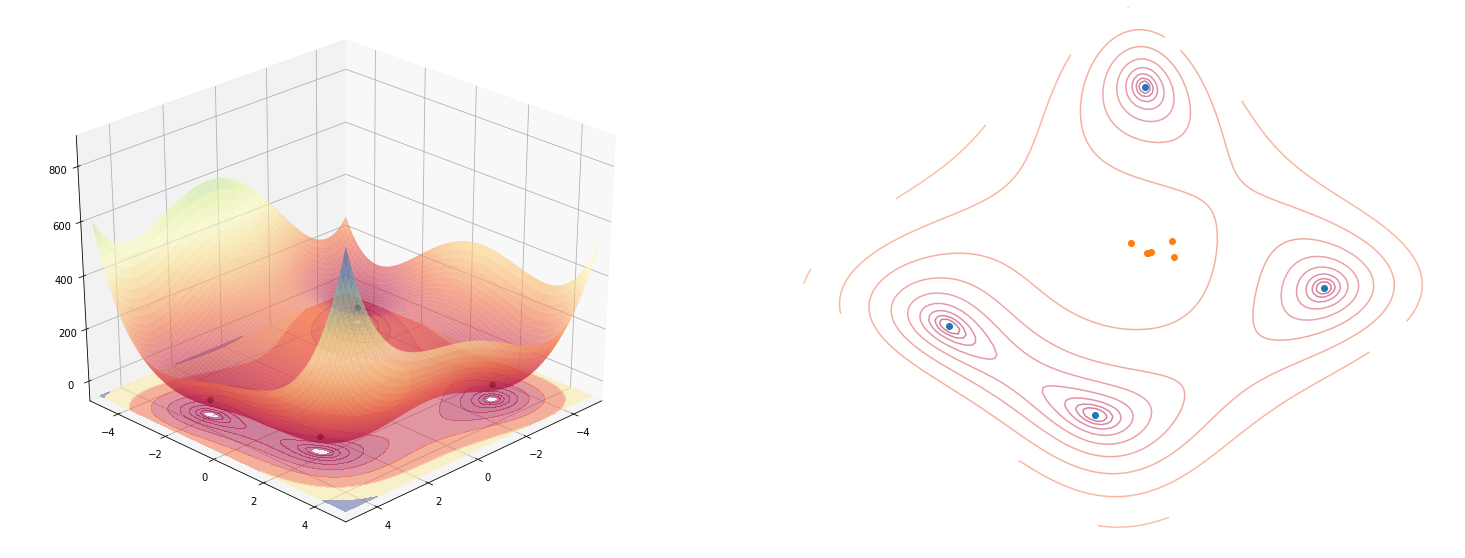

In [ ]:
from optimisations.functions import himmelblau
from optimisations.graphics import plot_function

angle=45
function = himmelblau()
fix, ax_3d, ax_2d = plot_function(function, angle=angle)

state = init([3.1413, 1.4137], population_size=6)
print(state)

# plot the initial state
points = np.array([_decode(ind) for ind in state.generation])
ax_2d.scatter(points[:, 0], points[:, 1], label="old")

iterations = 100
for i in range(iterations):
    state = update(i, function, state)
    print(state)
    points = np.array([_decode(ind) for ind in state.generation])
    if i % 1000 == 0: 
        ax_2d.scatter(*rotate(points[:, 0], points[:, 1], angle=angle), alpha=(i*10+1)/(10*iterations), color="gray")
    print(f"Generation {i}")
    # print(state)

ax_2d.legend()
print(state)
# print(new_state)
# print(np.round(points[:, 0], 2))
# print(np.round(points[:, 1], 2))

In [ ]:
from functools import partial

def genetic_algo(population_size=50, max_offset=4):
    print(f"Genetic_algo: population_size={population_size}")
    return partial(init, population_size=population_size, max_offset=max_offset), update, get_params

In [ ]:
optimisation = (
    optimize(himmelblau())
        .using(genetic_algo(population_size=20), name="ga", derivatives_based=False)
        .start_from([-1., 1.])
) 

history = optimisation.update(3)
print(history[-1])
print([optimisation._get_params(state) for state in history])

In [ ]:
def decorate_with_derivative_free_plot(name_of_optimizer: str, history: np.ndarray, figure: Figure):
    # we asume that history is a list of list of points
    # each sub-list is one timestep in the iteration, ie. a generation
    # each element of the sub-list is the position of a single individual
    
    levels = min(len(history), levels)

    transparency_levels = (np.geomspace(1, 2, num=(levels+1)) - 1)[1:]
    colors = ['gray'] * (levels - 1) + ['orange']
    for gen, state, alpha, color in zip(range(len(history) - levels, len(history)), history[-levels:], transparency_levels, colors):
        points = np.array([_decode(ind) for ind in state.generation])
        figure.ax_2d.scatter(*rotate(points[:, 0], points[:, 1], angle=figure.angle), alpha=alpha, color=color, label=f"gen_{gen}")
        # ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        #         verticalalignment='top', bbox=props)


In [ ]:
function = himmelblau()
animate(
    optimize(himmelblau())
        .using(
            genetic_algo(population_size=10), 
            name="ga", 
            derivatives_based=False, 
            render_decorator=decorate_with_derivative_free_plot
        )
        .start_from([-1., 1.]),
    frames=10,
    interval=50,
    figure=Figure(
        fig=plt.figure(figsize=(13,5)), 
        contour_log_scale=False,
    ).for_function(function)
);